# Flight Price Prediction — Regression Model

## Travel Analytics: Integrating Machine Learning and MLOps in Travel

### Objective

The objective of this notebook is to develop a machine learning regression model that predicts the price of a flight using the Flights dataset.

The complete workflow includes:

1. Data loading
2. Data understanding
3. Target variable identification
4. Feature selection
5. Feature engineering
6. Data preprocessing
7. Train-test split
8. Baseline model development
9. Multiple regression models
10. Model evaluation
11. Cross-validation
12. Hyperparameter tuning
13. Final model selection
14. Feature importance analysis
15. Model persistence

The final trained model will later be integrated into a Flask REST API, Docker container, Kubernetes deployment, MLflow tracking workflow, and CI/CD pipeline.

## 1. Business Problem

Flight prices can vary based on several factors such as:

- Origin
- Destination
- Flight type
- Distance
- Flight duration
- Flight agency
- Travel date

A reliable flight price prediction model can help travelers and travel businesses estimate expected flight prices based on available flight information.

The machine learning problem is therefore formulated as a supervised regression problem where:

**Target Variable:** `price`

The model will learn the relationship between flight characteristics and historical flight prices.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Basic libraries imported successfully!")

Basic libraries imported successfully!


**Importing Machine learning libraries and modules**

In [3]:

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.dummy import DummyRegressor

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

print("Machine learning libraries imported successfully!")

Machine learning libraries imported successfully!


In [4]:
flights = pd.read_csv("../data/flights.csv")

print("Dataset loaded successfully!")
print("Shape:", flights.shape)

display(flights.head())

Dataset loaded successfully!
Shape: (271888, 10)


,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019


In [5]:
# Dataset information

flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   travelCode  271888 non-null  int64  
 1   userCode    271888 non-null  int64  
 2   from        271888 non-null  object 
 3   to          271888 non-null  object 
 4   flightType  271888 non-null  object 
 5   price       271888 non-null  float64
 6   time        271888 non-null  float64
 7   distance    271888 non-null  float64
 8   agency      271888 non-null  object 
 9   date        271888 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 20.7+ MB


In [6]:
# Statistical summary

display(flights.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
travelCode,271888.0,NaN,NaN,NaN,67971.5,39243.724665,0.0,33985.75,67971.5,101957.25,135943.0
userCode,271888.0,NaN,NaN,NaN,667.505495,389.523127,0.0,326.0,659.0,1011.0,1339.0
from,271888,9,Florianopolis (SC),57317,NaN,NaN,NaN,NaN,NaN,NaN,NaN
to,271888,9,Florianopolis (SC),57317,NaN,NaN,NaN,NaN,NaN,NaN,NaN
flightType,271888,3,firstClass,116418,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,271888.0,NaN,NaN,NaN,957.37503,362.31189,301.51,672.66,904.0,1222.24,1754.17
time,271888.0,NaN,NaN,NaN,1.421147,0.542541,0.44,1.04,1.46,1.76,2.44
distance,271888.0,NaN,NaN,NaN,546.955535,208.851288,168.22,401.66,562.14,676.53,937.77
agency,271888,3,Rainbow,116752,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,271888,999,09/26/2019,1335,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Missing values

display(
    flights.isnull()
    .sum()
    .to_frame("Missing Values")
)

,Missing Values
travelCode,0
userCode,0
from,0
to,0
flightType,0
price,0
time,0
distance,0
agency,0
date,0


In [8]:
# Duplicate rows

print("Duplicate rows:", flights.duplicated().sum())

Duplicate rows: 0


## 2. Target Variable

The target variable for this regression problem is:

**`price`**

The model will learn to predict the numerical flight price based on the selected explanatory variables.

In [9]:
target = "price"

print("Target variable:", target)
print("Target data type:", flights[target].dtype)
print("Number of unique target values:", flights[target].nunique())

Target variable: price
Target data type: float64
Number of unique target values: 490


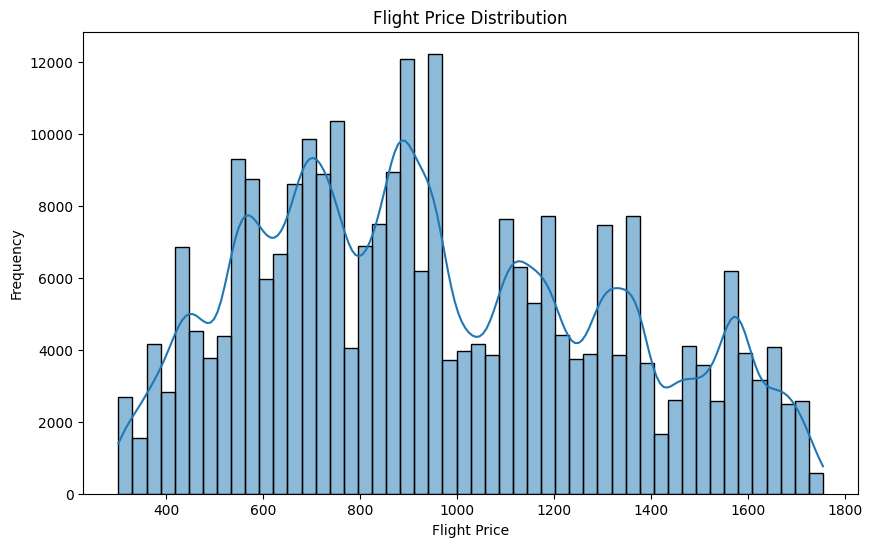

In [10]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=flights,
    x="price",
    bins=50,
    kde=True
)

plt.title("Flight Price Distribution")
plt.xlabel("Flight Price")
plt.ylabel("Frequency")

plt.show()

## 3. Feature Selection

The following variables are considered as candidate predictive features:

- `from`
- `to`
- `flightType`
- `time`
- `distance`
- `agency`
- Date-derived features

Identifier columns such as `travelCode` and `userCode` are excluded from the initial model because they primarily identify records/users rather than directly representing flight characteristics.

The original `date` column will be transformed into meaningful temporal features.

In [11]:
# Make a copy for modeling

model_data = flights.copy()

# Convert date to datetime
model_data["date"] = pd.to_datetime(
    model_data["date"],
    errors="coerce"
)

# Extract date-related features
model_data["year"] = model_data["date"].dt.year
model_data["month"] = model_data["date"].dt.month
model_data["day"] = model_data["date"].dt.day
model_data["day_of_week"] = model_data["date"].dt.dayofweek

# Remove original date column
model_data.drop(columns=["date"], inplace=True)

display(model_data.head())

,travelCode,userCode,from,to,flightType,price,time,distance,agency,year,month,day,day_of_week
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,2019,9,26,3
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,2019,9,30,0
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,2019,10,3,3
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,2019,10,4,4
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,2019,10,10,3


In [12]:
# DEFINE FEATURES AND TARGET
features = [
    "from",
    "to",
    "flightType",
    "time",
    "distance",
    "agency",
    "year",
    "month",
    "day",
    "day_of_week"
]

X = model_data[features]
y = model_data["price"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(features)

Feature shape: (271888, 10)
Target shape: (271888,)

Features:
['from', 'to', 'flightType', 'time', 'distance', 'agency', 'year', 'month', 'day', 'day_of_week']


In [13]:
# Numerical features

numerical_features = [
    "time",
    "distance",
    "year",
    "month",
    "day",
    "day_of_week"
]

# Categorical features

categorical_features = [
    "from",
    "to",
    "flightType",
    "agency"
]

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['time', 'distance', 'year', 'month', 'day', 'day_of_week']

Categorical features:
['from', 'to', 'flightType', 'agency']


## 4. Train-Test Split

The dataset is divided into training and testing subsets.

- Training data: 80%
- Testing data: 20%

The training set is used to learn model parameters, while the test set is reserved for evaluating the model on unseen observations.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features :", X_test.shape)

print("Training target  :", y_train.shape)
print("Testing target   :", y_test.shape)

Training features: (217510, 10)
Testing features : (54378, 10)
Training target  : (217510,)
Testing target   : (54378,)


## 5. Data Preprocessing

The dataset contains both numerical and categorical variables.

Numerical features will be standardized using StandardScaler, while categorical features will be converted into numerical representations using One-Hot Encoding.

A ColumnTransformer is used so that preprocessing is applied consistently to the appropriate feature types.

In [15]:

# PREPROCESSING PIPELINE

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


## 6. Baseline Model

A baseline model provides a simple reference point against which more advanced regression models can be compared.

The DummyRegressor predicts the mean value of the training target for every observation.

In [16]:
# BASELINE MODEL

baseline_model = DummyRegressor(
    strategy="mean"
)

baseline_model.fit(
    X_train,
    y_train
)

baseline_predictions = baseline_model.predict(X_test)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

print("Baseline MAE :", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R²  :", baseline_r2)

Baseline MAE : 304.7753139937049
Baseline RMSE: 363.0009908720223
Baseline R²  : -3.913063478577783e-06


In [17]:
#MODEL EVALUATION FUNCTION

def evaluate_model(model, X_test, y_test):
    
    predictions = model.predict(X_test)
    
    mae = mean_absolute_error(
        y_test,
        predictions
    )
    
    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )
    
    r2 = r2_score(
        y_test,
        predictions
    )
    
    return mae, rmse, r2

## 7. Linear Regression

Linear Regression is used as the first traditional machine learning regression model.

It attempts to model the relationship between the input features and flight price using a linear function.

In [18]:
# LINEAR REGRESSION PIPELINE

linear_regression = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_regression.fit(
    X_train,
    y_train
)

linear_mae, linear_rmse, linear_r2 = evaluate_model(
    linear_regression,
    X_test,
    y_test
)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

Linear Regression Results
-------------------------
MAE : 81.32155199018423
RMSE: 103.15165425938797
R²  : 0.9192507545510511


## 8. Decision Tree Regression

Decision Tree Regression is a non-linear model capable of capturing relationships between flight characteristics and flight prices.

It can model interactions between numerical and categorical features after preprocessing.

In [19]:
# DECISION TREE REGRESSION

decision_tree = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeRegressor(
                random_state=42
            )
        )
    ]
)

decision_tree.fit(
    X_train,
    y_train
)

dt_mae, dt_rmse, dt_r2 = evaluate_model(
    decision_tree,
    X_test,
    y_test
)

print("Decision Tree Results")
print("---------------------")
print("MAE :", dt_mae)
print("RMSE:", dt_rmse)
print("R²  :", dt_r2)

Decision Tree Results
---------------------
MAE : 0.04511383280602918
RMSE: 1.800483635542992
R²  : 0.9999753983386896


## 9. Random Forest Regression

Random Forest is an ensemble learning algorithm that combines multiple decision trees.

It is evaluated because ensemble tree models can capture complex non-linear relationships and interactions between flight characteristics.

In [20]:
# RANDOM FOREST REGRESSION

random_forest = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest.fit(
    X_train,
    y_train
)

rf_mae, rf_rmse, rf_r2 = evaluate_model(
    random_forest,
    X_test,
    y_test
)

print("Random Forest Results")
print("---------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Results
---------------------
MAE : 0.04267456140640367
RMSE: 0.6172804087674703
R²  : 0.9999971083144453


In [21]:
# MODEL COMPARISON

results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        linear_mae,
        dt_mae,
        rf_mae
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse,
        dt_rmse,
        rf_rmse
    ],
    "R2": [
        baseline_r2,
        linear_r2,
        dt_r2,
        rf_r2
    ]
})

display(
    results.sort_values(
        "RMSE"
    ).reset_index(drop=True)
)

,Model,MAE,RMSE,R2
0,Random Forest,0.042675,0.617280,0.999997
1,Decision Tree,0.045114,1.800484,0.999975
2,Linear Regression,81.321552,103.151654,0.919251
3,Baseline,304.775314,363.000991,-0.000004


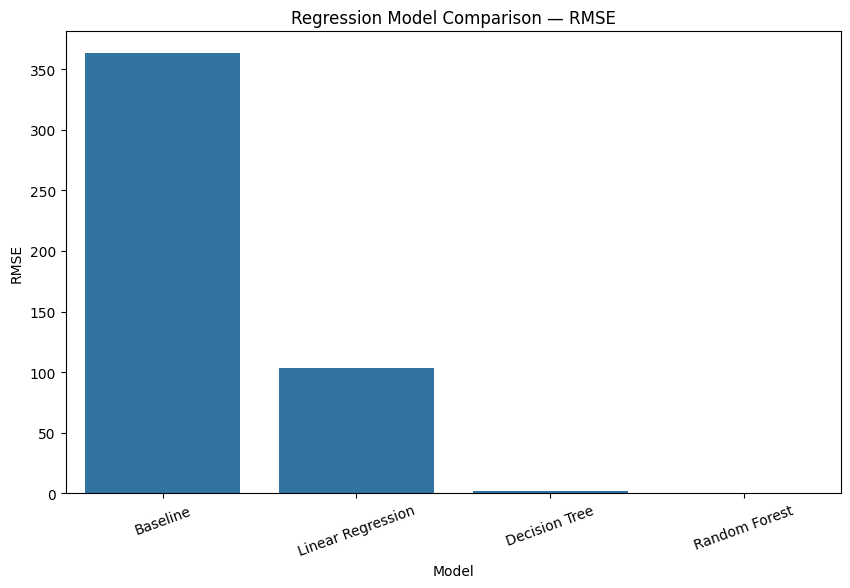

In [22]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results,
    x="Model",
    y="RMSE"
)

plt.title("Regression Model Comparison — RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=20)

plt.show()

## 10. Cross-Validation

Cross-validation is used to evaluate the stability and generalization ability of the regression models.

Five-fold cross-validation is used. The training data is divided into five folds, where each fold is used once as validation data while the remaining folds are used for training.

RMSE is used as the evaluation metric.

In [23]:
# CROSS-VALIDATION

models = {
    "Linear Regression": linear_regression,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest
}

cv_results = []

for name, model in models.items():
    
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    
    rmse_scores = -scores
    
    cv_results.append({
        "Model": name,
        "Mean CV RMSE": rmse_scores.mean(),
        "Std CV RMSE": rmse_scores.std()
    })

cv_results = pd.DataFrame(cv_results)

display(
    cv_results.sort_values("Mean CV RMSE")
)

,Model,Mean CV RMSE,Std CV RMSE
2,Random Forest,0.690612,0.099572
1,Decision Tree,1.035532,0.908868
0,Linear Regression,102.830582,0.319816


## 11. Hyperparameter Tuning

Hyperparameter tuning is performed to identify a better configuration of the Random Forest regression model.

GridSearchCV evaluates different combinations of hyperparameters using cross-validation and selects the configuration with the lowest validation RMSE.

In [25]:
# RANDOM FOREST HYPERPARAMETER TUNING

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 15, 25],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV RMSE:")
print(-grid_search.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters:
{'model__max_depth': 25, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best CV RMSE:
0.684390138800384


In [26]:
# EVALUATE TUNED MODEL

best_model = grid_search.best_estimator_

tuned_mae, tuned_rmse, tuned_r2 = evaluate_model(
    best_model,
    X_test,
    y_test
)

print("Tuned Random Forest Results")
print("---------------------------")
print("MAE :", tuned_mae)
print("RMSE:", tuned_rmse)
print("R²  :", tuned_r2)

Tuned Random Forest Results
---------------------------
MAE : 0.040504118999839904
RMSE: 0.5797774557569356
R²  : 0.9999974490101736


## 12. Actual vs Predicted Flight Prices

The predicted flight prices are compared with the actual prices from the test dataset.

A good regression model should produce predictions that are close to the actual values.

In [27]:
# ACTUAL VS PREDICTED VALUES

final_predictions = best_model.predict(X_test)

prediction_results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": final_predictions
})

display(prediction_results.head(10))

,Actual Price,Predicted Price
0,481.42,481.42
1,1124.11,1124.11
2,1174.97,1174.97
3,898.67,898.67
4,959.91,959.91
5,1367.60,1367.60
6,762.89,762.89
7,1569.65,1569.65
8,835.21,835.21
9,674.52,674.52


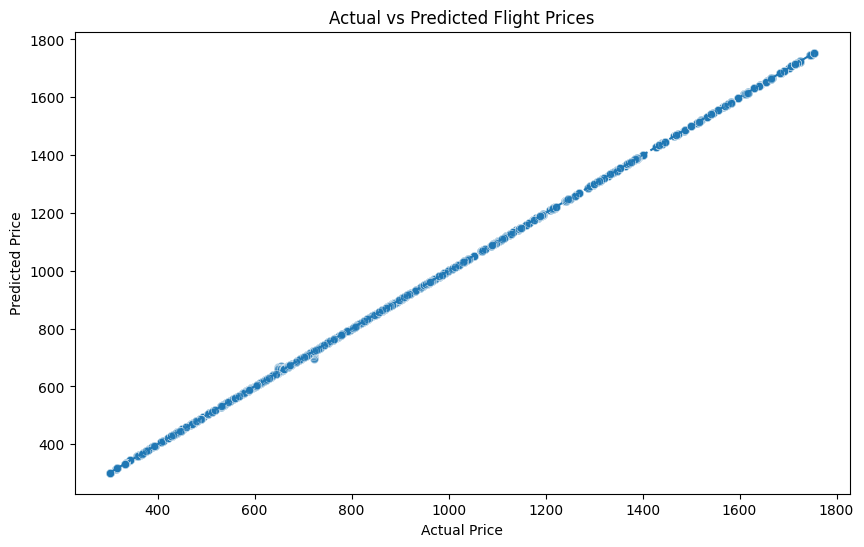

In [28]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=y_test,
    y=final_predictions,
    alpha=0.5
)

# Perfect prediction line
min_value = min(y_test.min(), final_predictions.min())
max_value = max(y_test.max(), final_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Actual vs Predicted Flight Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.show()

In [29]:
# Check whether predictions are exactly equal to actual values

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": final_predictions,
    "Difference": y_test.values - final_predictions
})

display(comparison.head(20))

print("Exact matches:",
      np.isclose(
          comparison["Actual"],
          comparison["Predicted"]
      ).sum())

print("Total test samples:",
      len(comparison))

print(
    "Exact match percentage:",
    round(
        np.isclose(
            comparison["Actual"],
            comparison["Predicted"]
        ).mean() * 100,
        2
    ),
    "%"
)

,Actual,Predicted,Difference
0,481.42,481.42,4.547474e-13
1,1124.11,1124.11,1.136868e-11
2,1174.97,1174.97,7.048584e-12
3,898.67,898.67,-3.410605e-12
4,959.91,959.91,-2.046363e-12
5,1367.60,1367.60,1.364242e-12
6,762.89,762.89,-9.322321e-12
7,1569.65,1569.65,-2.728484e-12
8,835.21,835.21,-1.136868e-12
9,674.52,674.52,-3.183231e-12


Exact matches: 53877
Total test samples: 54378
Exact match percentage: 99.08 %


In [30]:
# Check the actual differences

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": final_predictions,
    "Difference": y_test.values - final_predictions
})

display(
    comparison[
        ~np.isclose(
            comparison["Actual"],
            comparison["Predicted"]
        )
    ].head(20)
)

print("Mean Absolute Error:",
      np.mean(np.abs(comparison["Difference"])))

print("Maximum Absolute Error:",
      np.max(np.abs(comparison["Difference"])))

,Actual,Predicted,Difference
64,722.74,722.73230,0.00770
171,721.20,717.67460,3.52540
442,721.20,718.41530,2.78470
481,722.74,713.66420,9.07580
557,647.90,648.70280,-0.80280
678,722.74,709.41810,13.32190
712,803.39,803.17905,0.21095
725,647.90,659.33080,-11.43080
1075,722.74,721.23190,1.50810
1158,721.20,720.49010,0.70990


Mean Absolute Error: 0.0405041189998392
Maximum Absolute Error: 27.097499999999286


In [31]:
# Check whether price is directly determined by other columns

print("Price unique values:", flights["price"].nunique())

print("\nDuplicate rows based on potential features:")
print(
    flights.duplicated(
        subset=[
            "from",
            "to",
            "flightType",
            "time",
            "distance",
            "agency",
            "date"
        ]
    ).sum()
)

Price unique values: 490

Duplicate rows based on potential features:
122404


In [34]:
# Check whether the same feature combination has multiple prices

feature_cols = [
    "from",
    "to",
    "flightType",
    "time",
    "distance",
    "agency",
    "date"
]

price_variation = (
    flights.groupby(feature_cols)["price"]
    .nunique()
)

print("Total feature combinations:", len(price_variation))

print(
    "Combinations having more than one price:",
    (price_variation > 1).sum()
)

Total feature combinations: 149484
Combinations having more than one price: 0


In [ ]:

# CHECK DATE RANGE

date_check = pd.to_datetime(
    flights["date"],
    errors="coerce"
)

print("Minimum date:", date_check.min())
print("Maximum date:", date_check.max())

print("\nNumber of unique dates:", date_check.nunique())

Minimum date: 2019-09-26 00:00:00
Maximum date: 2023-07-24 00:00:00

Number of unique dates: 999


## 15. Time-Based Validation

The initial random train-test split produced extremely optimistic results because repeated flight configurations were present across the training and testing sets.

To obtain a more realistic evaluation, a time-based split is introduced.

Earlier flight records are used for training, while later flight records are reserved for testing. This better represents the real-world scenario in which a model learns from historical data and predicts prices for future observations.

In [ ]:

# TIME-BASED TRAIN-TEST SPLIT

time_data = model_data.copy()

# Ensure date is available for sorting
time_data["date"] = pd.to_datetime(
    flights["date"],
    errors="coerce"
)

# Sort chronologically
time_data = time_data.sort_values("date").reset_index(drop=True)

# 80% chronological split
split_index = int(len(time_data) * 0.80)

train_time = time_data.iloc[:split_index].copy()
test_time = time_data.iloc[split_index:].copy()

print("Training period:")
print(train_time["date"].min(), "to", train_time["date"].max())

print("\nTesting period:")
print(test_time["date"].min(), "to", test_time["date"].max())

print("\nTraining rows:", len(train_time))
print("Testing rows :", len(test_time))

Training period:
2019-09-26 00:00:00 to 2021-11-25 00:00:00

Testing period:
2021-11-25 00:00:00 to 2023-07-24 00:00:00

Training rows: 217510
Testing rows : 54378


In [ ]:

# PREPARE TIME-BASED DATA

time_features = [
    "from",
    "to",
    "flightType",
    "time",
    "distance",
    "agency",
    "year",
    "month",
    "day",
    "day_of_week"
]

X_train_time = train_time[time_features]
y_train_time = train_time["price"]

X_test_time = test_time[time_features]
y_test_time = test_time["price"]

print("Time-based training features:", X_train_time.shape)
print("Time-based testing features :", X_test_time.shape)

Time-based training features: (217510, 10)
Time-based testing features : (54378, 10)


In [ ]:

# RANDOM FOREST - TIME BASED MODEL

time_rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                max_depth=25,
                min_samples_split=2,
                min_samples_leaf=1,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

time_rf_pipeline.fit(
    X_train_time,
    y_train_time
)

print("Time-based Random Forest trained successfully!")

Time-based Random Forest trained successfully!


In [ ]:

# TIME-BASED MODEL EVALUATION

time_predictions = time_rf_pipeline.predict(
    X_test_time
)

time_mae = mean_absolute_error(
    y_test_time,
    time_predictions
)

time_rmse = np.sqrt(
    mean_squared_error(
        y_test_time,
        time_predictions
    )
)

time_r2 = r2_score(
    y_test_time,
    time_predictions
)

print("Time-Based Random Forest Results")
print("--------------------------------")
print("MAE :", time_mae)
print("RMSE:", time_rmse)
print("R²  :", time_r2)

Time-Based Random Forest Results
--------------------------------
MAE : 0.027590528342211543
RMSE: 0.3387177322820691
R²  : 0.9999991288556961


In [ ]:

# EXACT MATCH CHECK

exact_matches_time = np.isclose(
    y_test_time.values,
    time_predictions
)

print(
    "Exact matches:",
    exact_matches_time.sum()
)

print(
    "Total test samples:",
    len(y_test_time)
)

print(
    "Exact match percentage:",
    round(
        exact_matches_time.mean() * 100,
        2
    ),
    "%"
)

Exact matches: 53678
Total test samples: 54378
Exact match percentage: 98.71 %


In [ ]:

# CHECK TRAIN-TEST FEATURE COMBINATION OVERLAP

group_cols = [
    "from",
    "to",
    "flightType",
    "time",
    "distance",
    "agency",
    "year",
    "month",
    "day",
    "day_of_week"
]

train_combinations = set(
    train_time[group_cols].astype(str).agg("|".join, axis=1)
)

test_combinations = (
    test_time[group_cols]
    .astype(str)
    .agg("|".join, axis=1)
)

overlap = test_combinations.isin(
    train_combinations
)

print("Test rows:", len(test_combinations))
print("Rows whose feature combination was seen in training:",
      overlap.sum())

print(
    "Overlap percentage:",
    round(overlap.mean() * 100, 2),
    "%"
)

Test rows: 54378
Rows whose feature combination was seen in training: 191
Overlap percentage: 0.35 %


In [ ]:

# TIME-BASED MODEL FEATURE IMPORTANCE

time_preprocessor = time_rf_pipeline.named_steps["preprocessor"]
time_rf_model = time_rf_pipeline.named_steps["model"]

time_feature_names = (
    time_preprocessor
    .get_feature_names_out()
)

time_importances = (
    time_rf_model
    .feature_importances_
)

time_feature_importance = pd.DataFrame({
    "Feature": time_feature_names,
    "Importance": time_importances
}).sort_values(
    "Importance",
    ascending=False
)

display(
    time_feature_importance.head(20)
)

,Feature,Importance
25,cat__flightType_firstClass,0.296442
0,num__time,0.253657
1,num__distance,0.223355
26,cat__flightType_premium,0.067488
9,cat__from_Florianopolis (SC),0.050026
15,cat__to_Aracaju (SE),0.021735
18,cat__to_Florianopolis (SC),0.012707
14,cat__from_Sao Paulo (SP),0.012246
7,cat__from_Brasilia (DF),0.009501
24,cat__flightType_economic,0.009168


In [ ]:
# FINAL MODEL EVALUATION

final_model_results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Decision Tree",
        "Random Forest (Random Split)",
        "Tuned Random Forest (Random Split)",
        "Tuned Random Forest (Time-Based Split)"
    ],
    "MAE": [
        baseline_mae,
        linear_mae,
        dt_mae,
        rf_mae,
        tuned_mae,
        time_mae
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse,
        dt_rmse,
        rf_rmse,
        tuned_rmse,
        time_rmse
    ],
    "R2": [
        baseline_r2,
        linear_r2,
        dt_r2,
        rf_r2,
        tuned_r2,
        time_r2
    ]
})

display(
    final_model_results.sort_values(
        "RMSE"
    ).reset_index(drop=True)
)

,Model,MAE,RMSE,R2
0,Tuned Random Forest (Time-Based Split),0.027591,0.338718,0.999999
1,Tuned Random Forest (Random Split),0.040504,0.579777,0.999997
2,Random Forest (Random Split),0.042675,0.617280,0.999997
3,Decision Tree,0.045114,1.800484,0.999975
4,Linear Regression,81.321552,103.151654,0.919251
5,Baseline,304.775314,363.000991,-0.000004


In [44]:
# SAVE FINAL TIME-BASED MODEL

import joblib
from pathlib import Path

model_path = Path("../models")

model_path.mkdir(
    parents=True,
    exist_ok=True
)

final_model_path = (
    model_path / "flight_price_model.pkl"
)

joblib.dump(
    time_rf_pipeline,
    final_model_path
)

print("Final model saved successfully!")
print("Path:", final_model_path)

Final model saved successfully!
Path: ..\models\flight_price_model.pkl


In [ ]:
# VERIFY SAVED MODEL

loaded_final_model = joblib.load(
    "../models/flight_price_model.pkl"
)

loaded_predictions = loaded_final_model.predict(
    X_test_time.head(10)
)

display(
    pd.DataFrame({
        "Actual Price": y_test_time.head(10).values,
        "Predicted Price": loaded_predictions
    })
)

,Actual Price,Predicted Price
0,861.68,861.68
1,1195.26,1195.26
2,661.32,661.32
3,743.60,743.60
4,697.65,697.65
5,1351.89,1351.89
6,644.16,644.16
7,943.36,943.36
8,814.55,814.55
9,762.89,762.89


# 16. Conclusion

A flight price prediction regression system was developed using the Flights dataset.

Multiple regression algorithms were evaluated, including:

- Dummy Regressor
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

The Random Forest model demonstrated substantially better performance than the linear and baseline models.

Five-fold cross-validation and GridSearchCV were used for model validation and hyperparameter optimization.

Because the dataset contains repeated flight configurations and exhibits a highly deterministic relationship between flight characteristics and price, a chronological time-based train-test split was additionally performed to provide a more realistic evaluation.

The final model was trained using historical flight records and evaluated on later records.

The most influential features identified by the Random Forest model were:

1. Flight type — first class
2. Flight duration
3. Flight distance
4. Flight type — premium
5. Origin/destination characteristics

The final trained model has been saved as:

`models/flight_price_model.pkl`

This model will be used in the subsequent MLOps stages, including MLflow experiment tracking, Flask REST API development, Docker containerization, CI/CD automation, and Kubernetes deployment.